# Week 2
- Loading the dataset 
- Analysing Structure

In [39]:
import numpy as np
import pandas as pd
df=pd.read_csv("./data/framingham.csv")

In [40]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [41]:
df.shape

(4238, 16)

In [42]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

# Week 3
- Handling the Missing Values
- Handling the Outliers Values

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.impute import SimpleImputer
from scipy.stats import zscore

In [44]:
df = pd.read_csv("./data/framingham.csv")

## Handling Missing Values

**Imputation:** null Imputated data

In [45]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

**Selecting Numerical and Categorical Columns**

- Categoical columns

In [46]:
categorical_cols = [
    "education",
    "currentSmoker",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes"
]

- Numerical columns

In [47]:
numerical_cols = [
    "cigsPerDay",
    "totChol",
    "BMI",
    "heartRate",
    "glucose",
    "sysBP",
    "diaBP"
]

**Imputation:** Categorical Attributes (Mode)

In [48]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

**output:** Categorical Attributed Imputated

In [49]:
df.isnull().sum()

male                 0
age                  0
education            0
currentSmoker        0
cigsPerDay          29
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

**Imputation:** Numerical Attributes (Median)

In [50]:
num_imputer = SimpleImputer(strategy="median")

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])


**output:** Categorical Attributed Imputated

In [51]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

## Handling Outlier Values

**Outlier Dectection:** Numerical attributes

- Using Boxplot

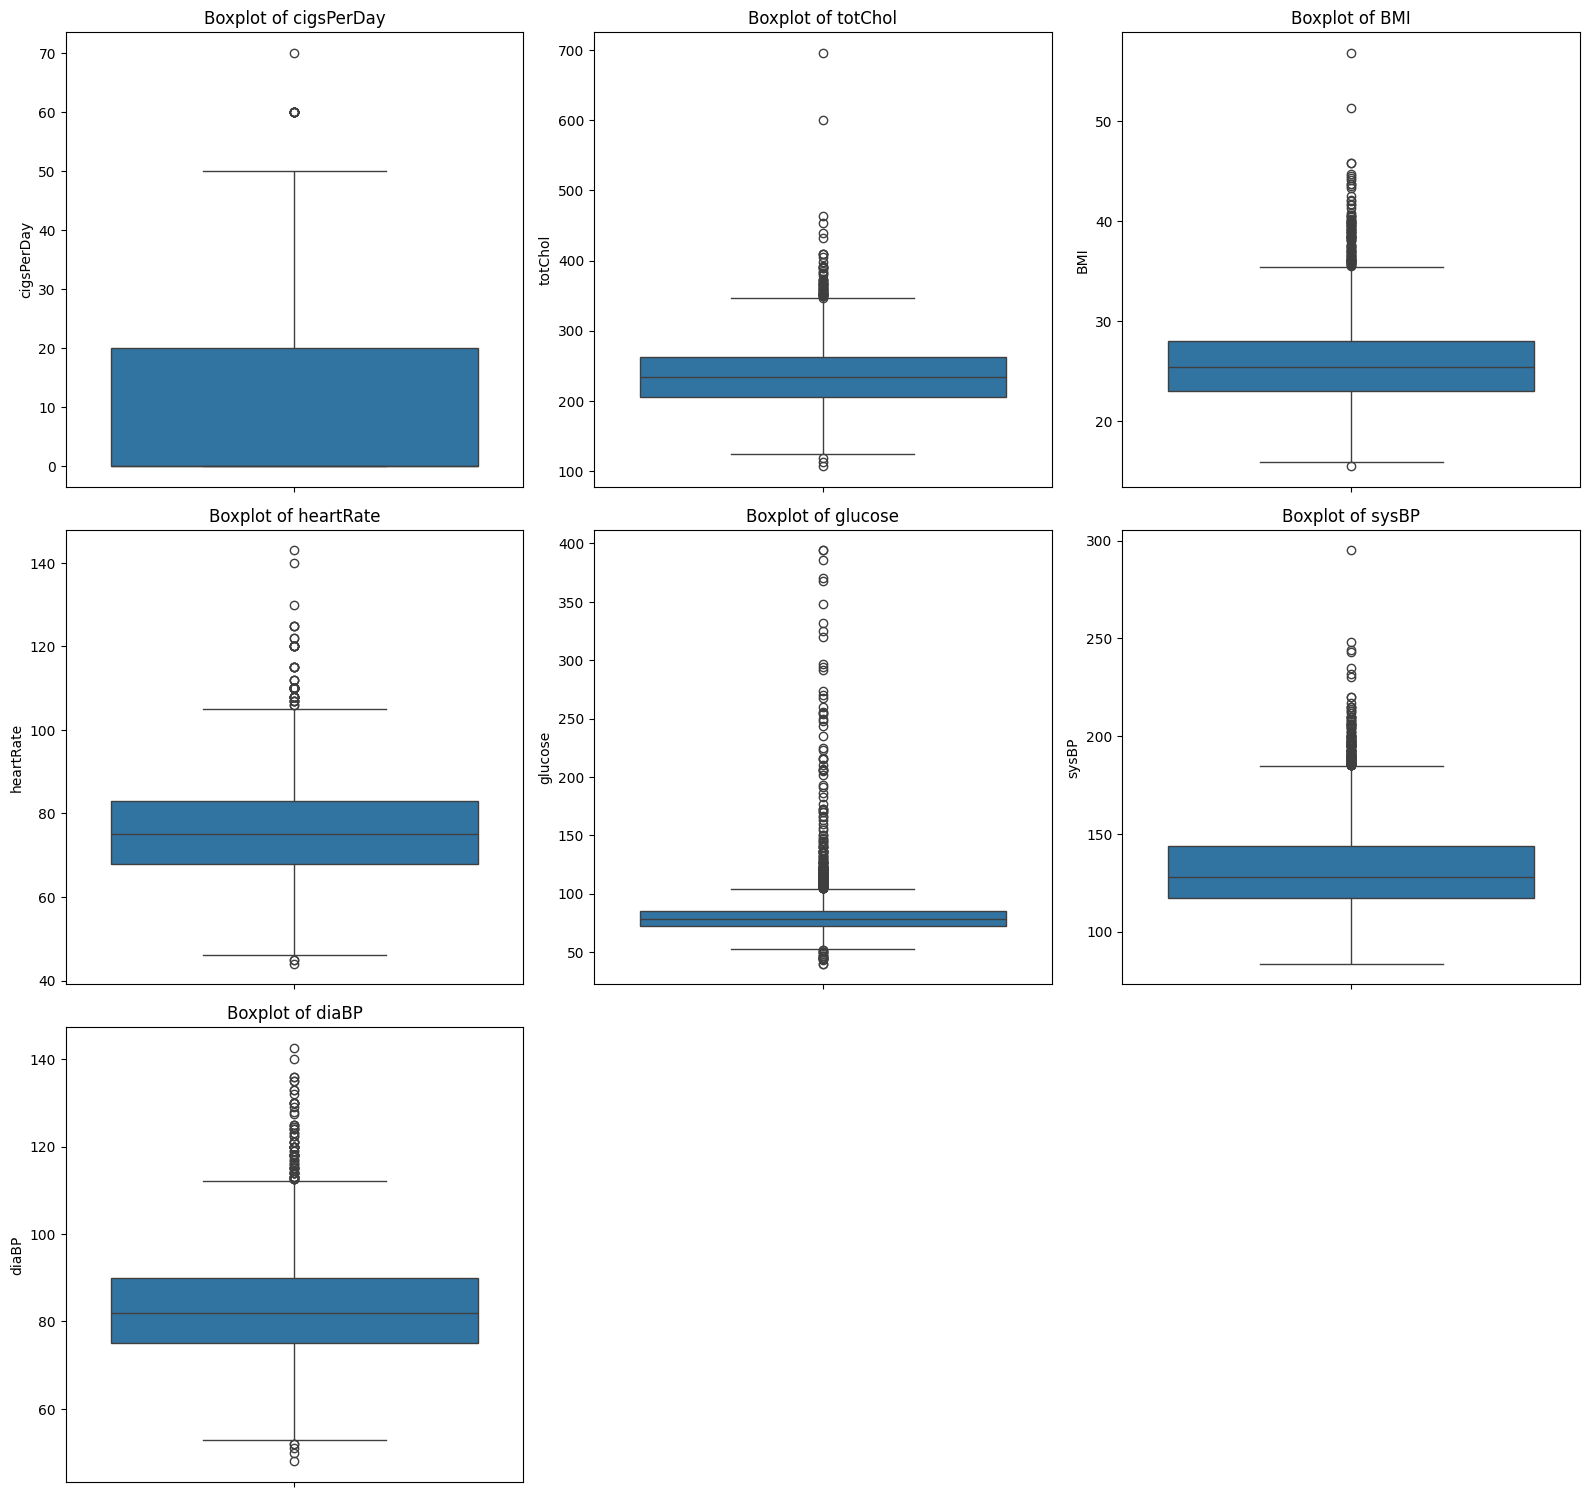

In [52]:
plt.figure(figsize=(16, 20))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


- Using Z-Score

In [53]:
z_scores = df[numerical_cols].apply(zscore)

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()
outlier_count


cigsPerDay    21
totChol       25
BMI           60
heartRate     23
glucose       50
sysBP         48
diaBP         41
dtype: int64

**Outlier Fixing:** Numerical attributes

- Outlirs Columns 

In [54]:
outlier_cols = [
    "cigsPerDay",
    "totChol",
    "BMI",
    "heartRate",
    "glucose",
    "sysBP",
    "diaBP"
]

- IQR Capping Function

In [55]:
def iqr_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(lower_bound, upper_bound)

- Apply Capping to Each Attribute

In [56]:
for col in outlier_cols:
    iqr_capping(df, col)

- Verify Outliers After Treatment

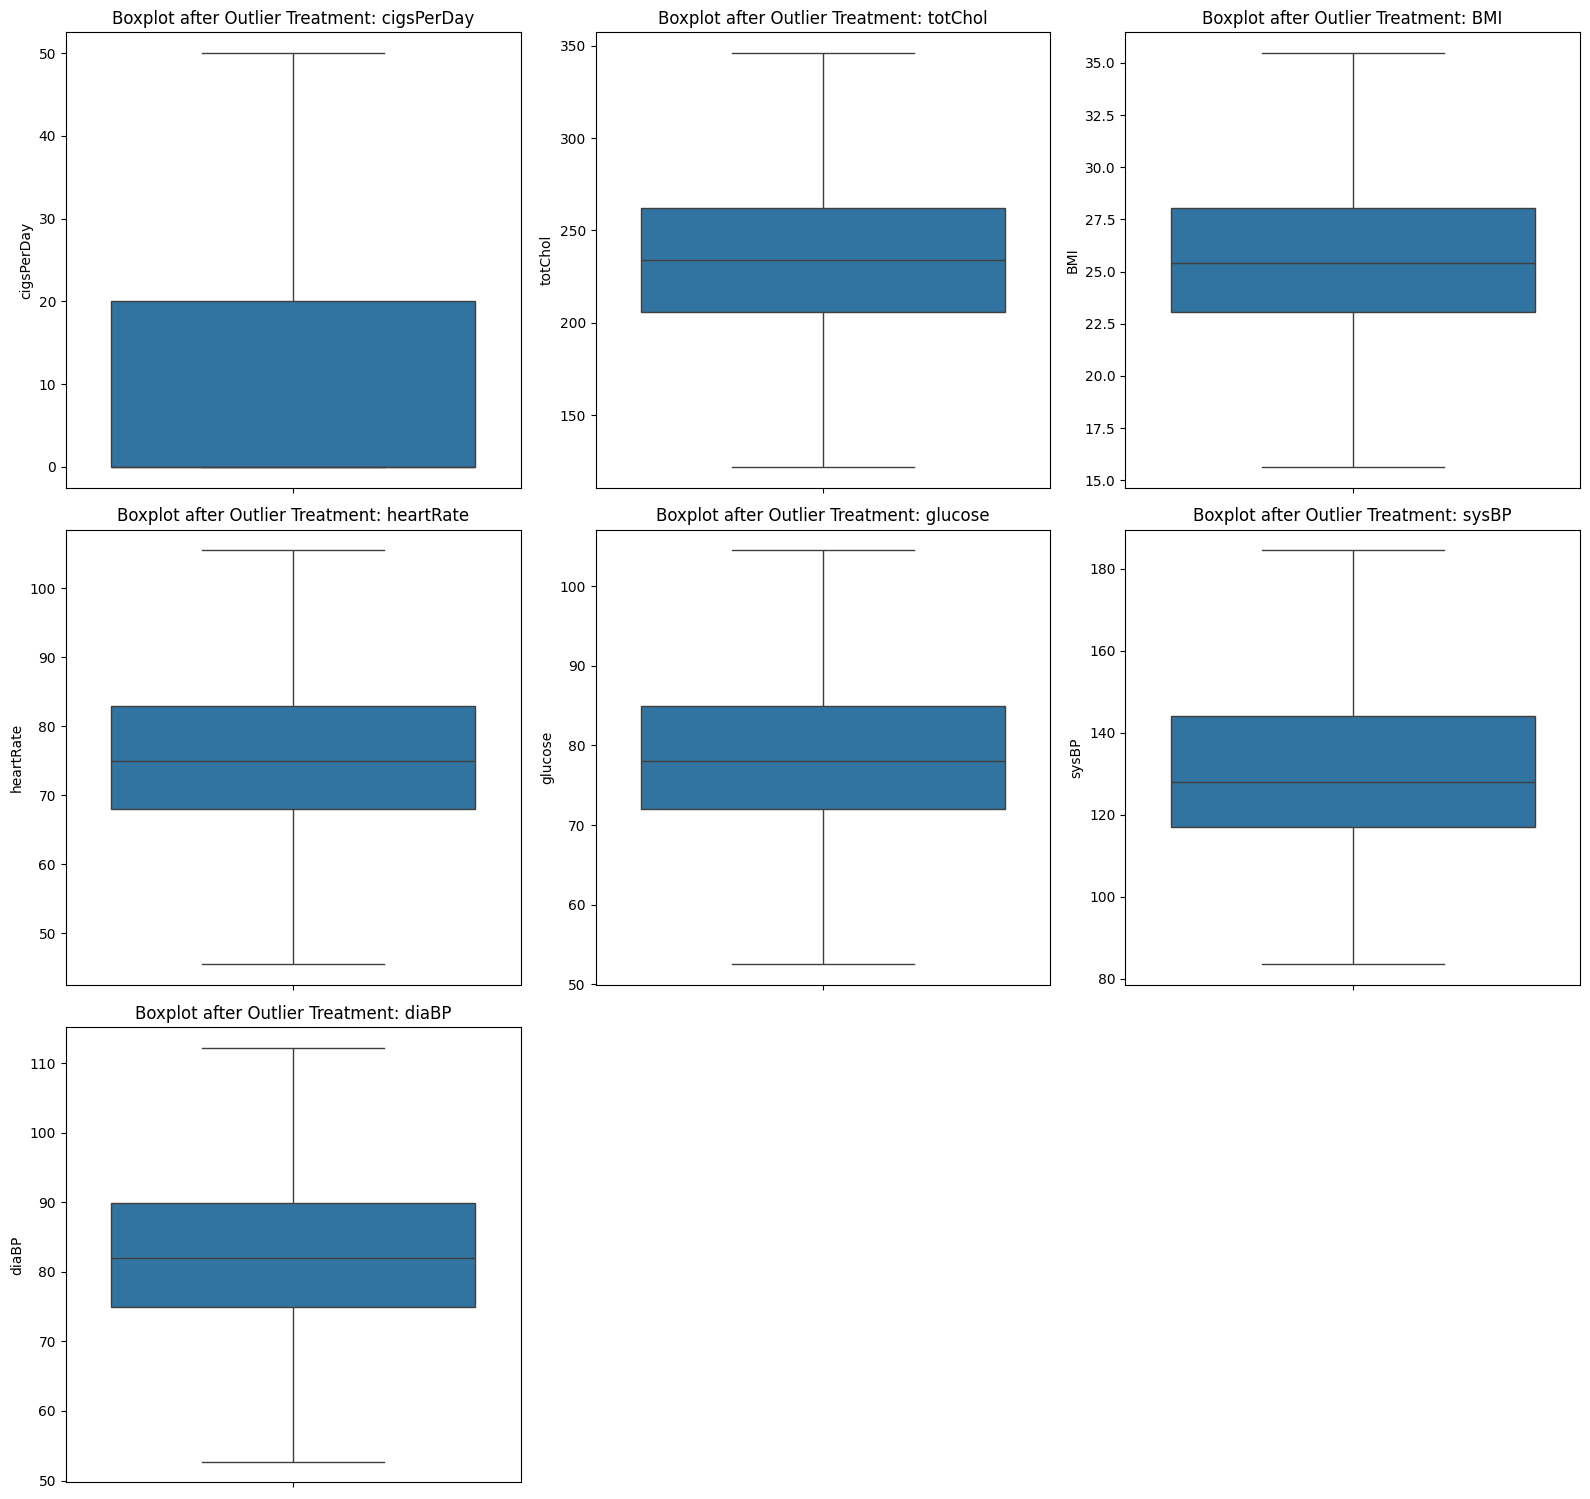

In [57]:
plt.figure(figsize=(16, 20))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot after Outlier Treatment: {col}")

plt.tight_layout()
plt.show()

# Week 4
- Univariate and Bivariate analysis.
- Visualizing distributions. 

## Variate Analysis

### Univariate Analysis

**Why we use Univariate Analysis**<br/>
- To understand the individual behavior of each variable
- To detect skewness, outliers, and imbalance
<br/>

**What is relevant for this dataset**
- Identify imbalance in TenYearCHD
- Study distributions of clinical features such as blood pressure, glucose, BMI
- Detect abnormal medical values

**TenYearCHD Distribution**

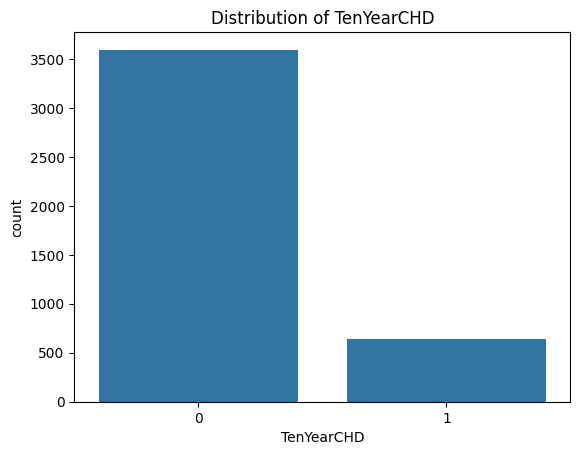

In [58]:
sns.countplot(x='TenYearCHD', data=df)
plt.title("Distribution of TenYearCHD")
plt.show()

**Continuous Variable Distribution**

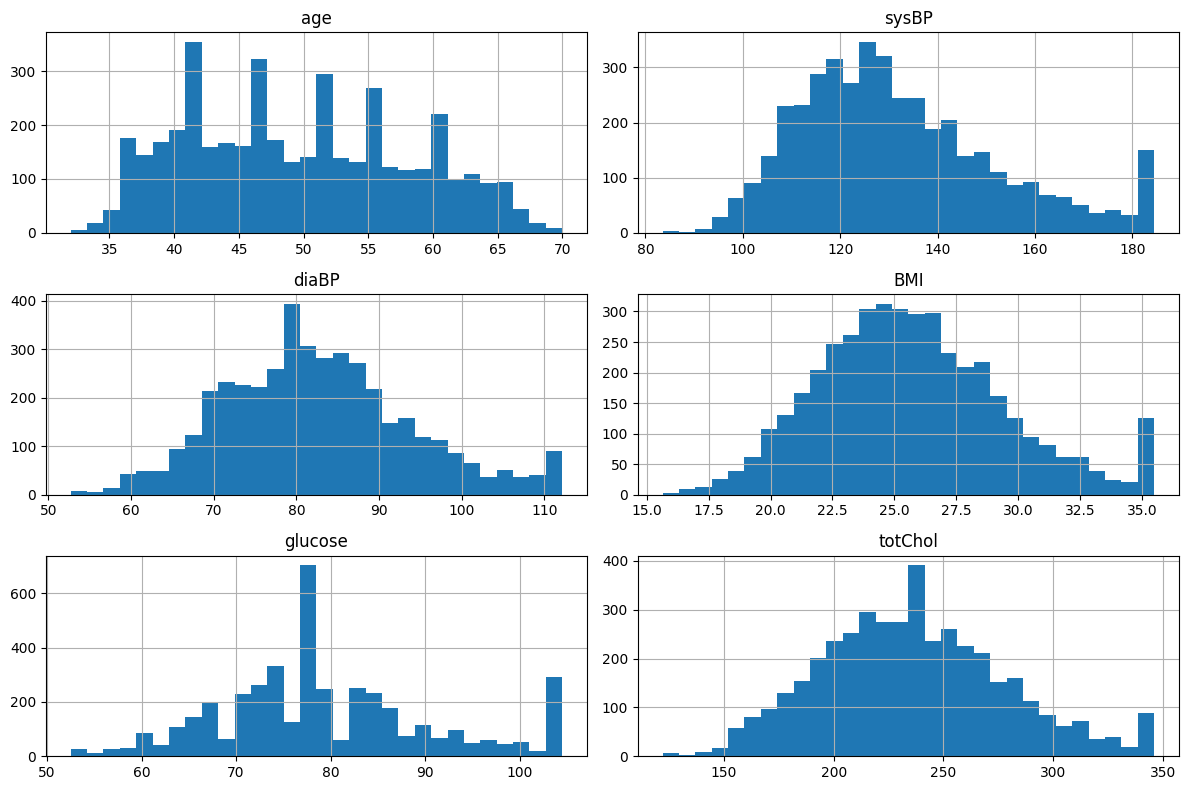

In [59]:
num_cols = ['age', 'sysBP', 'diaBP', 'BMI', 'glucose', 'totChol']

df[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

**Univariate Observations**<br/>

- age, BMI, glucose show right-skewed distributions

- sysBP and diaBP are approximately normal

- Outliers present in glucose and cholesterol

### Bivariate Analysis

**Why we use Bivariate Analysis**

- To study relationship between features and target

- To identify risk factors

**What is relevant for this dataset**

- Clinical measurements vs CHD

- Lifestyle factors vs CHD


**Numerical Feature vs Target**

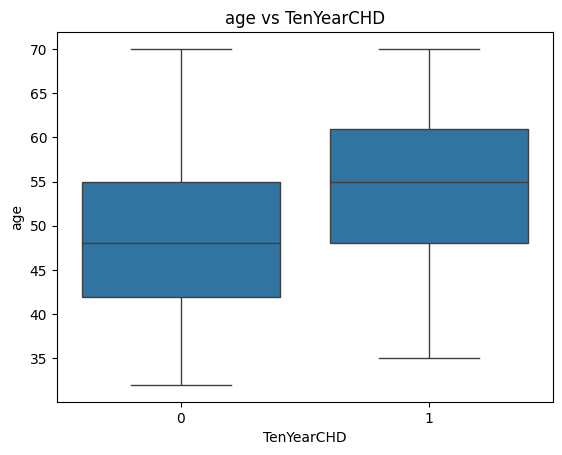

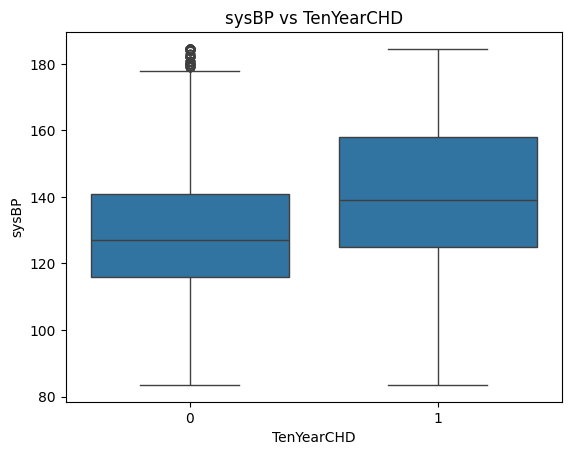

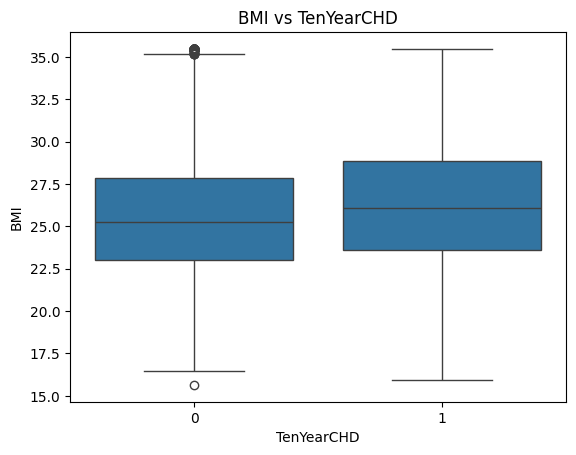

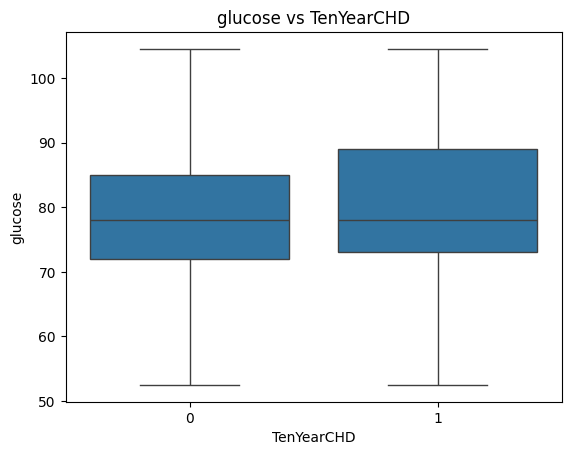

In [60]:
for col in ['age', 'sysBP', 'BMI', 'glucose']:
    sns.boxplot(x='TenYearCHD', y=col, data=df)
    plt.title(f"{col} vs TenYearCHD")
    plt.show()

**Categorical Feature vs Target**

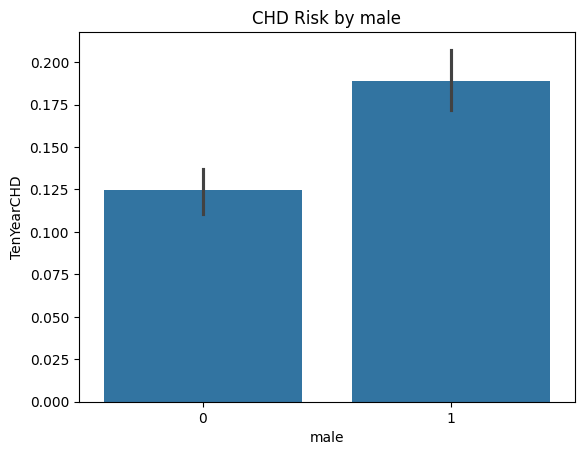

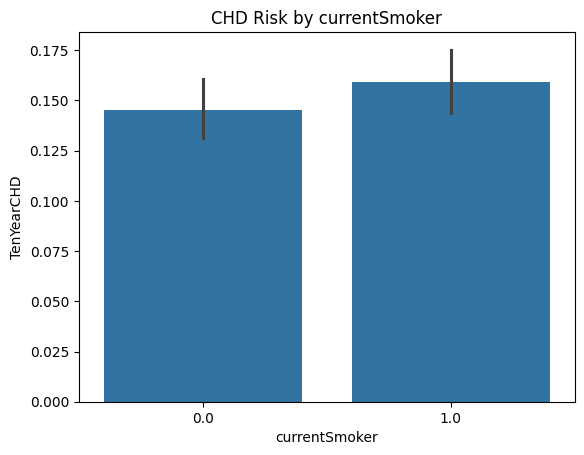

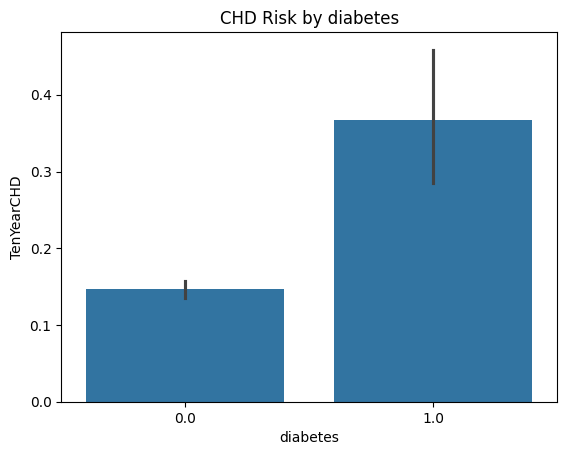

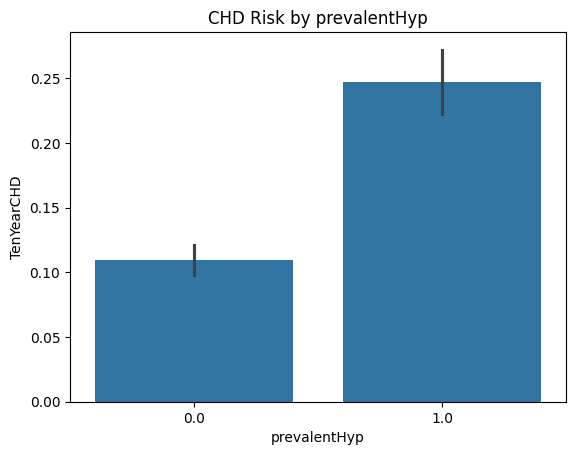

In [61]:
cat_cols = ['male', 'currentSmoker', 'diabetes', 'prevalentHyp']

for col in cat_cols:
    sns.barplot(x=col, y='TenYearCHD', data=df)
    plt.title(f"CHD Risk by {col}")
    plt.show()

**Bivariate Observations**

- CHD patients have higher median age and blood pressure

- Diabetes and hypertension show strong association with CHD

- Smoking increases CHD probability

### Multivariate Analysis

**Why we use Multivariate Analysis**
- To detect interactions among variables

- To identify multicollinearity

- To support dimensionality reduction

**What is relevant for this dataset**

- Blood pressure variables correlation

- Metabolic risk clustering

- Feature redundancy before modeling

**Correlation Matrix**

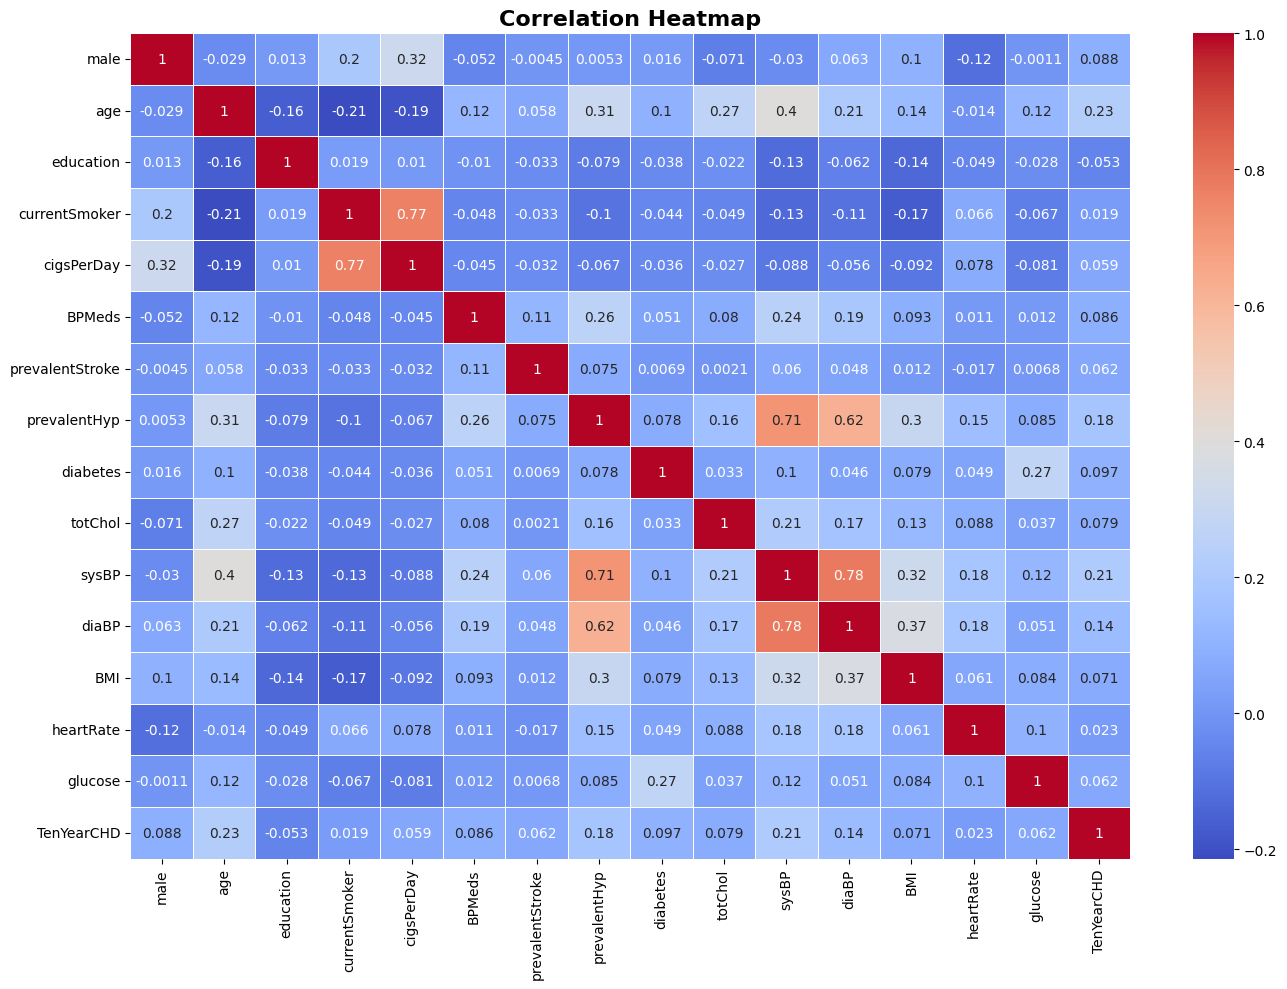

In [62]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(),
    mask=None,
    cmap='coolwarm',
    linewidths=0.5,
    annot=True
)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


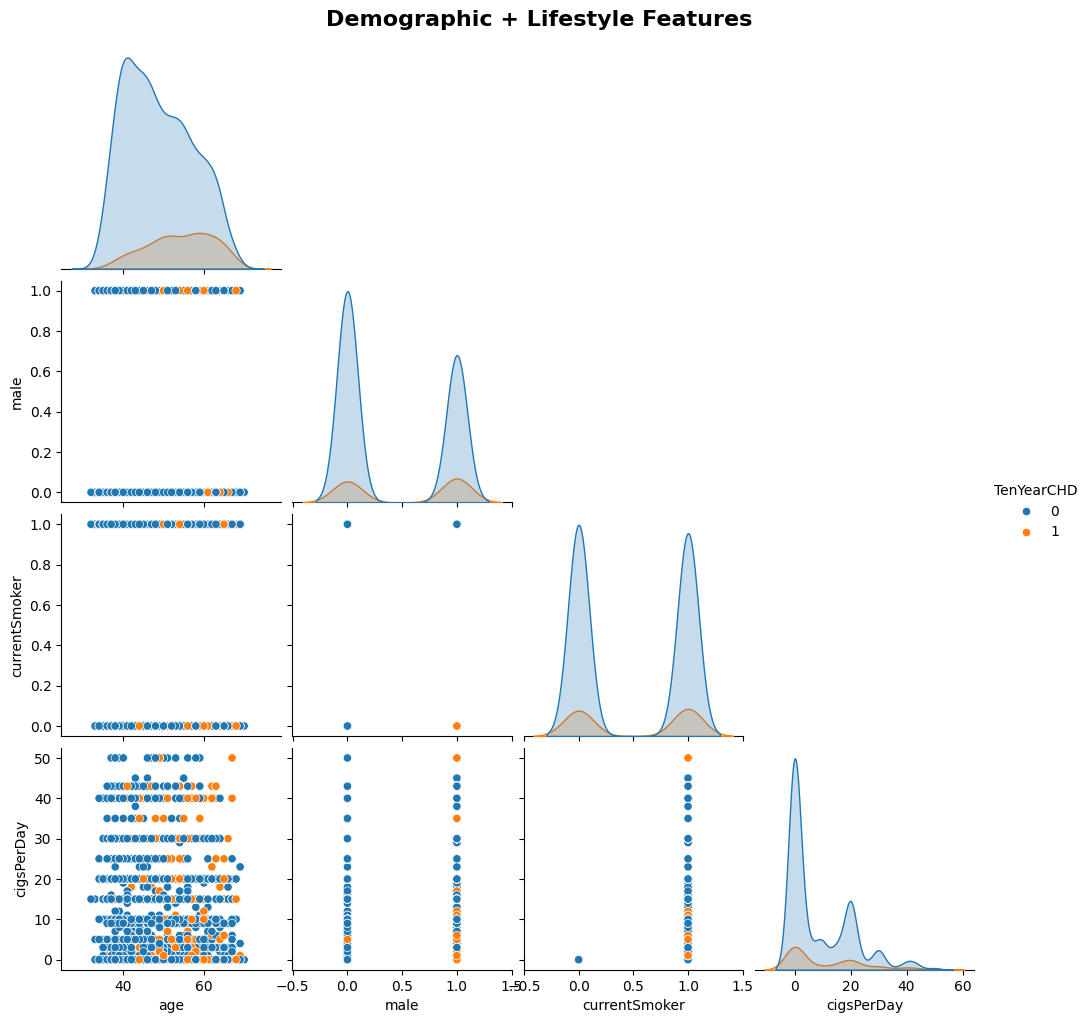

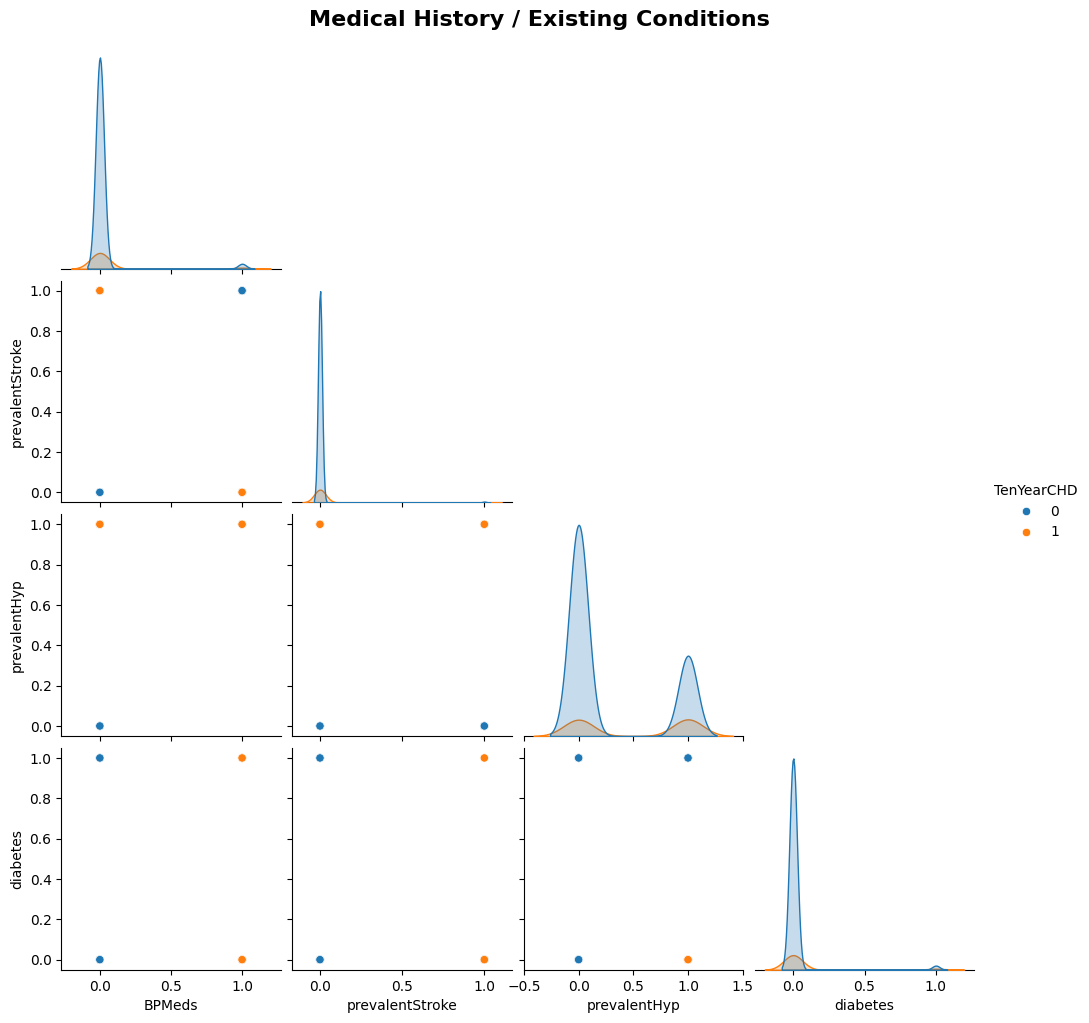

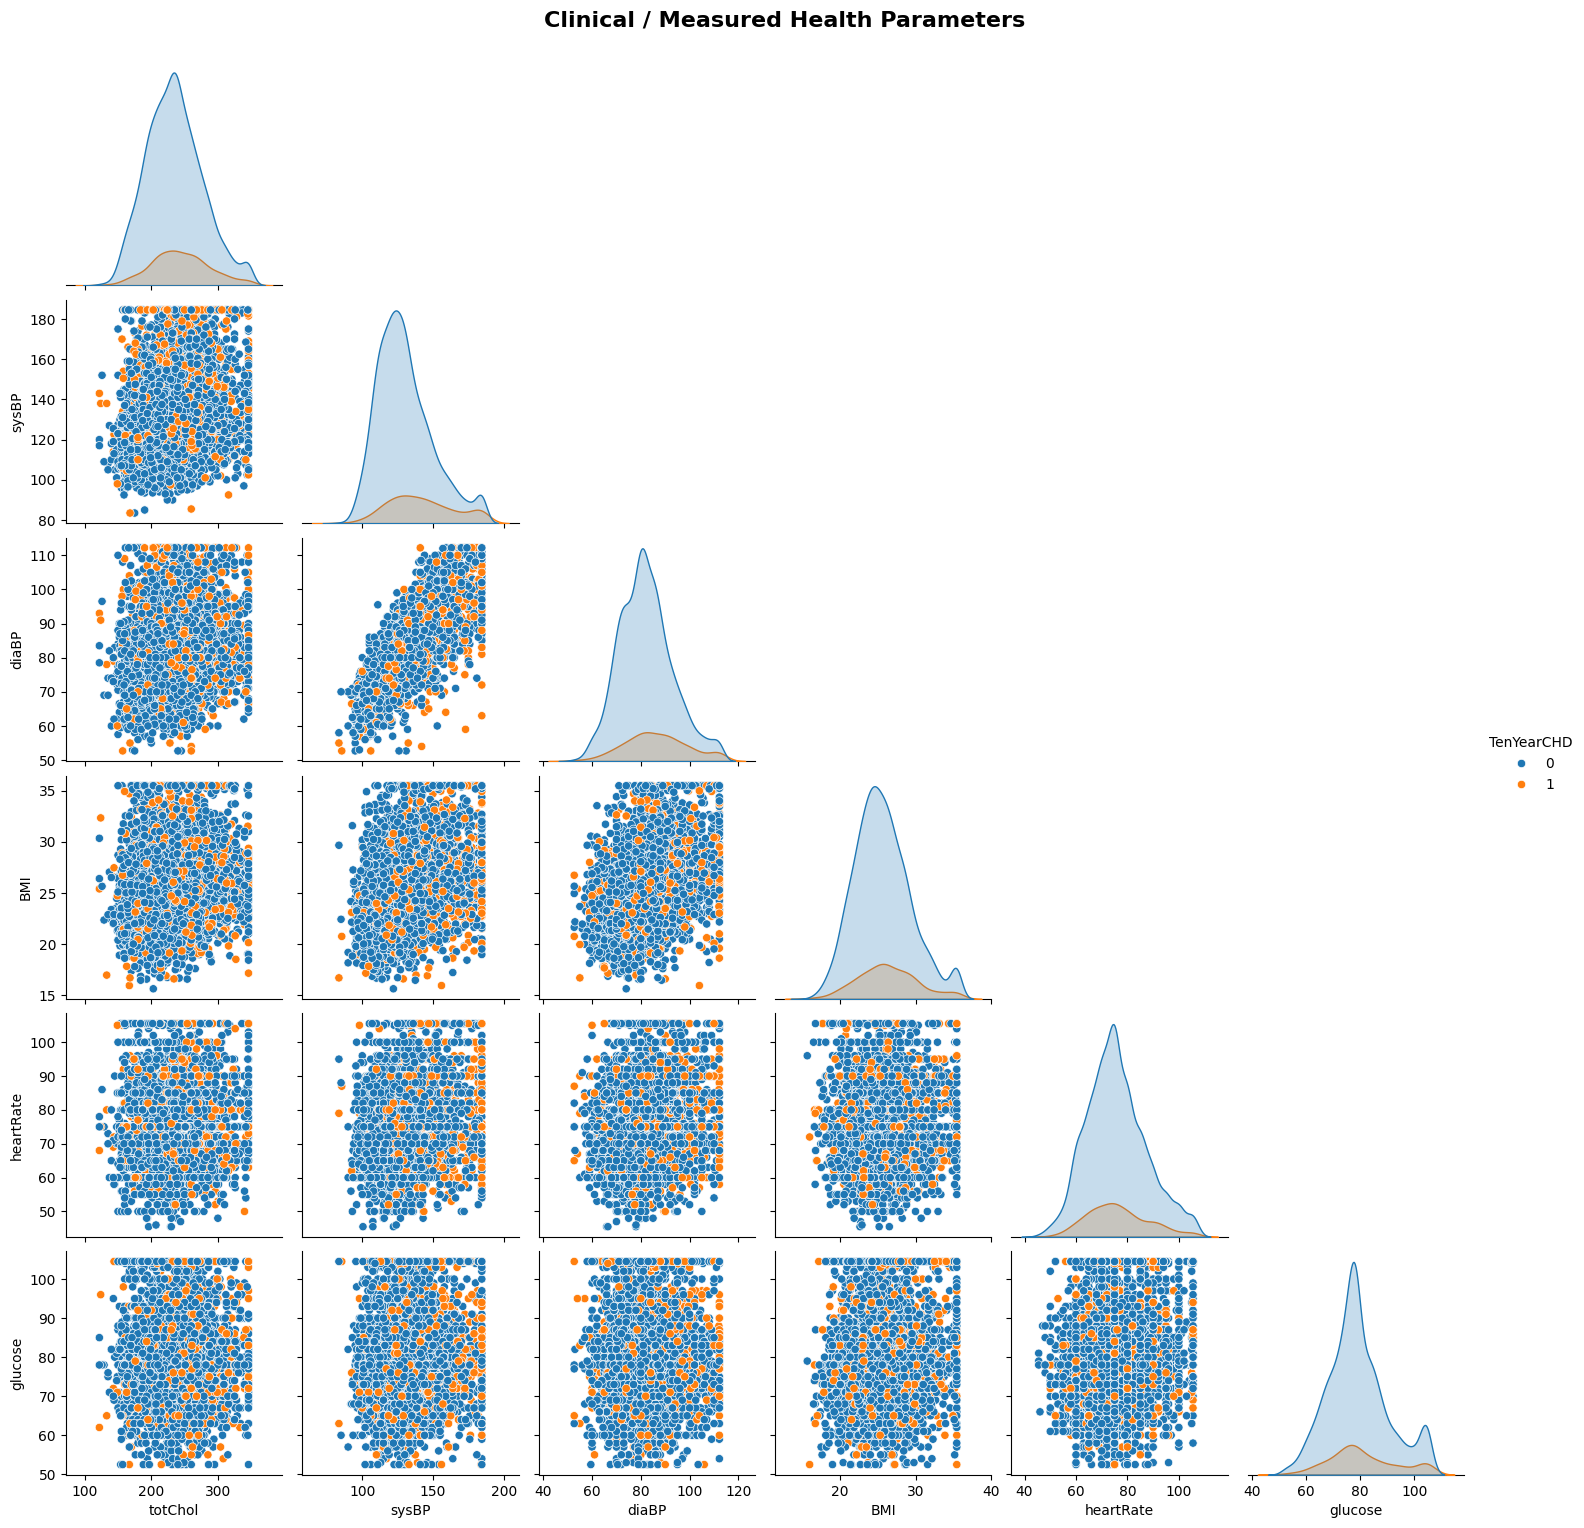

In [63]:
# Group 1: Demographic + lifestyle
cols1 = ['age', 'male', 'currentSmoker', 'cigsPerDay']

sns.pairplot(df[cols1 + ['TenYearCHD']], hue='TenYearCHD', diag_kind='kde', corner=True)
plt.suptitle("Demographic + Lifestyle Features", y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Group 2: Medical history
cols2 = ['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

sns.pairplot(df[cols2 + ['TenYearCHD']], hue='TenYearCHD', diag_kind='kde', corner=True)
plt.suptitle("Medical History / Existing Conditions", y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Group 3: Clinical measurements
cols3 = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

sns.pairplot(df[cols3 + ['TenYearCHD']], hue='TenYearCHD', diag_kind='kde', corner=True)
plt.suptitle("Clinical / Measured Health Parameters", y=1.02, fontsize=16, fontweight='bold')
plt.show()

**Multivariate Observations**
- Strong correlation between sysBP and diaBP

- BMI and glucose are positively correlated

- Multicollinearity exists and affects linear models

## Distribution Analysis

**KDE Distribution by Target**

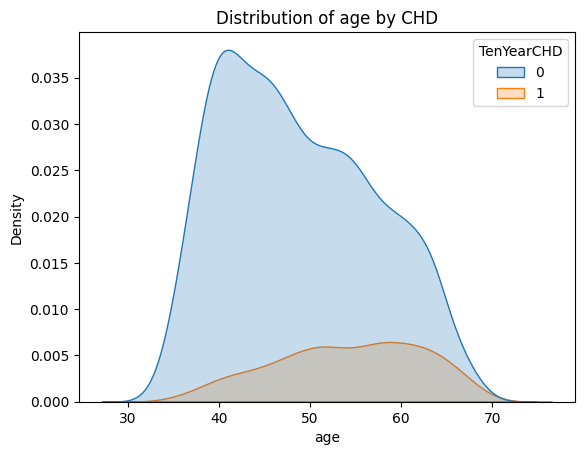

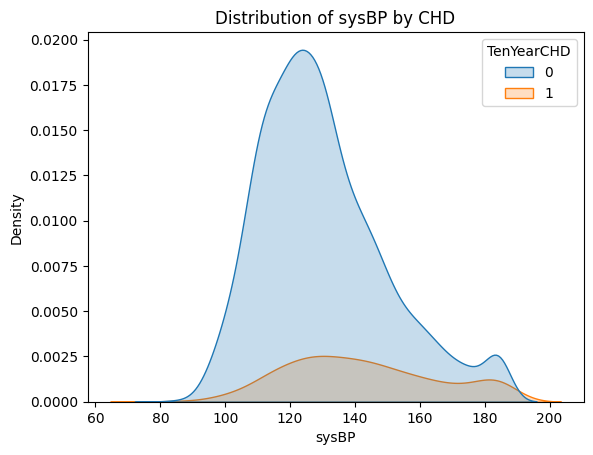

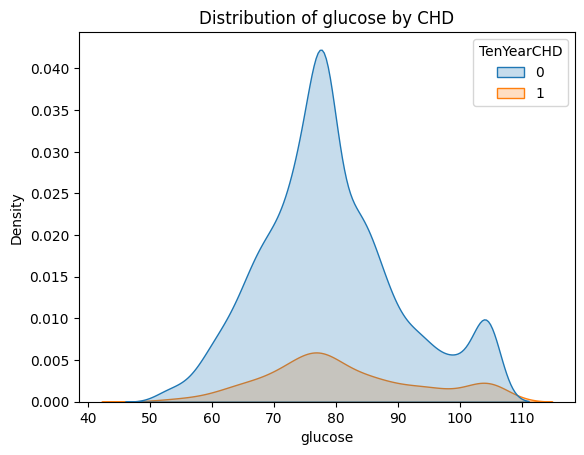

In [64]:
for col in ['age', 'sysBP', 'glucose']:
    sns.kdeplot(data=df, x=col, hue='TenYearCHD', fill=True)
    plt.title(f"Distribution of {col} by CHD")
    plt.show()

# Week 6 — Feature Engineering
**Goal:** Prepare the cleaned Framingham dataset for machine learning by:
1. Identifying and fixing skewed distributions
2. Scaling continuous features with the right scaler
3. Encoding the ordinal feature (`education`) correctly


## 6.0  Imports & Data Load

In [65]:
from scipy import stats
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

## 6.1  Column Taxonomy

Before applying any transformation we classify every column:

| Group | Columns | Reason |
|---|---|---|
| **Binary / Nominal** | `male`, `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes` | Already 0/1 — no encoding or scaling needed |
| **Ordinal** | `education` | 4-level ordered category (1 < 2 < 3 < 4) → ordinal encoding |
| **Continuous** | `age`, `cigsPerDay`, `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`, `glucose` | Require skew check + scaling |
| **Target** | `TenYearCHD` | Not transformed |

In [66]:
binary_cols     = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
ordinal_cols    = ['education']
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
target_col      = 'TenYearCHD' 

## 6.2  Skewness Detection

Skewness > **0.5** (moderate) or > **1.0** (high) indicates the distribution is
asymmetric enough to distort distance-based models and slow gradient descent.

| Range | Interpretation |
|---|---|
| −0.5 to 0.5 | Approximately symmetric — no fix needed |
| 0.5 to 1.0 | Moderate right skew — apply transformation |
| > 1.0 | High right skew — strong transformation required |

In [67]:
skewness = df[continuous_cols].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n")
print(skewness.to_string())

Skewness of continuous features:

cigsPerDay    1.180184
sysBP         0.732407
glucose       0.449353
BMI           0.438295
diaBP         0.404980
heartRate     0.403390
totChol       0.330328
age           0.228146


### Skewness Bar Chart

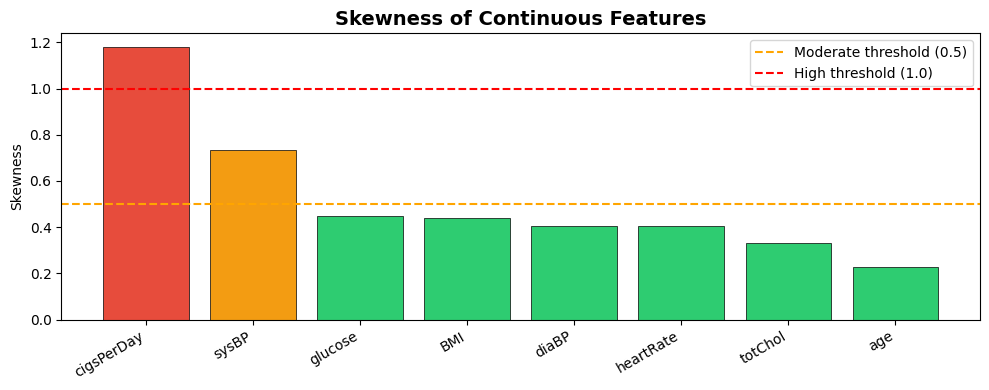

Red = high skew (>1), Orange = moderate (0.5–1), Green = acceptable (<0.5)


In [68]:
plt.figure(figsize=(10, 4))
colors = ['#e74c3c' if abs(s) > 1 else '#f39c12' if abs(s) > 0.5 else '#2ecc71'
          for s in skewness.values]
bars = plt.bar(skewness.index, skewness.values, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(0.5,  color='orange', linestyle='--', label='Moderate threshold (0.5)')
plt.axhline(1.0,  color='red',    linestyle='--', label='High threshold (1.0)')
plt.title("Skewness of Continuous Features", fontsize=14, fontweight='bold')
plt.ylabel("Skewness")
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print("Red = high skew (>1), Orange = moderate (0.5–1), Green = acceptable (<0.5)")

## 6.3  Fixing Skewness — Log1p Transform on `cigsPerDay`

`cigsPerDay` has the highest skew (**1.18**) because most patients smoke 0 cigarettes
(non-smokers) while a few smoke 40+. We apply **log1p** (`log(1 + x)`) which:
- Handles zero values safely (log(0) is undefined; log1p(0) = 0)
- Compresses the long right tail
- Reduces skew from 1.18 → ~0.32

We **replace** the original column so the pipeline is clean.

In [69]:
# Before
print(f"cigsPerDay  skew BEFORE: {df['cigsPerDay'].skew():.4f}")

df['cigsPerDay'] = np.log1p(df['cigsPerDay'])

# After
print(f"cigsPerDay  skew AFTER : {df['cigsPerDay'].skew():.4f}")

cigsPerDay  skew BEFORE: 1.1802
cigsPerDay  skew AFTER : 0.3200


### Visual Comparison — Before vs After Log Transform

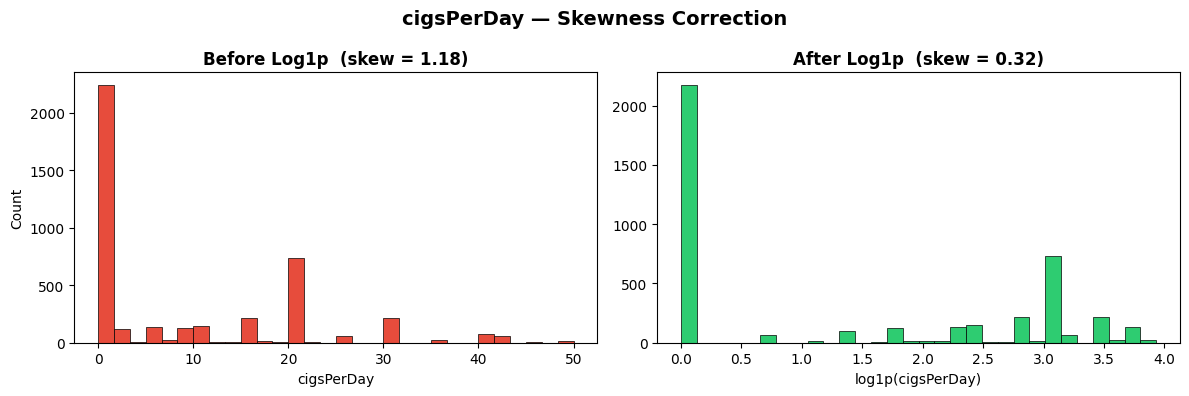

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orig_values = pd.read_csv("./data/ab.csv", index_col=0)['cigsPerDay']
axes[0].hist(orig_values, bins=30, color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[0].set_title(f"Before Log1p  (skew = {orig_values.skew():.2f})", fontweight='bold')
axes[0].set_xlabel("cigsPerDay")
axes[0].set_ylabel("Count")

axes[1].hist(df['cigsPerDay'], bins=30, color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[1].set_title(f"After Log1p  (skew = {df['cigsPerDay'].skew():.2f})", fontweight='bold')
axes[1].set_xlabel("log1p(cigsPerDay)")

plt.suptitle("cigsPerDay — Skewness Correction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.4  Ordinal Encoding — `education`

`education` already has numeric codes 1–4 from the source data, but Python stored
them as `float64` due to earlier imputation. We cast them to `int` to make the
ordinal nature explicit and prevent any floating-point noise.

The natural order is preserved: **1 = Some HS < 2 = HS Graduate < 3 = Some College < 4 = College**.

> **Why not One-Hot Encode?**  
> One-Hot Encoding (OHE) destroys the ordering. If we OHE education into 4 binary
> columns, the model cannot learn that level 4 > level 3. Because education has a
> clear natural order, ordinal encoding is the correct choice.

In [71]:
print("Before:", df['education'].dtype, "| Sample:", df['education'].unique())

df['education'] = df['education'].astype(int)

print("After :", df['education'].dtype, "| Sample:", sorted(df['education'].unique()))

Before: float64 | Sample: [4. 2. 1. 3.]
After : int64 | Sample: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Education Distribution

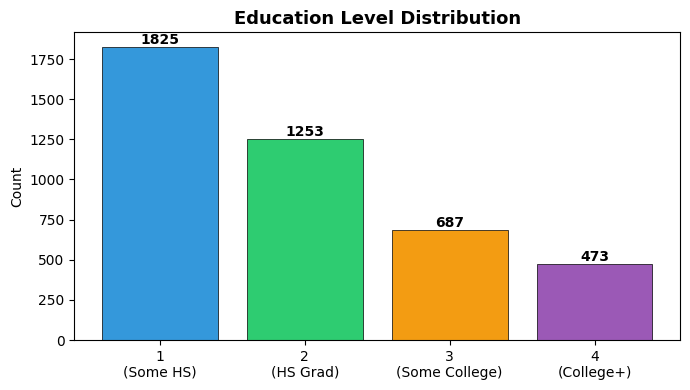

In [72]:
plt.figure(figsize=(7, 4))
counts = df['education'].value_counts().sort_index()
bars = plt.bar(['1\n(Some HS)', '2\n(HS Grad)', '3\n(Some College)', '4\n(College+)'],
               counts.values, color=['#3498db','#2ecc71','#f39c12','#9b59b6'],
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')
plt.title("Education Level Distribution", fontsize=13, fontweight='bold')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6.5  Scaling Continuous Features — RobustScaler

### Why RobustScaler over StandardScaler or MinMaxScaler?

| Scaler | Formula | Sensitive to Outliers? | Best when |
|---|---|---|---|
| **StandardScaler** | (x − mean) / std | ✅ Yes | Data is truly Gaussian |
| **MinMaxScaler** | (x − min) / (max − min) | ✅ Very much | No outliers at all |
| **RobustScaler** | (x − median) / IQR | ❌ No | Outliers present (like our dataset) |

Even after IQR capping in Week 3, our data still has borderline extreme values.
`RobustScaler` uses the **median** (not mean) and **IQR** (not std/range), making
it robust to any remaining extreme values. This is the right choice for clinical data.

In [73]:
scale_cols = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'cigsPerDay']

scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("After RobustScaler — descriptive statistics:")
df[scale_cols].describe().round(3)

After RobustScaler — descriptive statistics:


,age,totChol,sysBP,diaBP,BMI,heartRate,glucose,cigsPerDay
count,4238.000,4238.000,4238.000,4238.000,4238.000,4238.000,4238.000,4238.000
mean,0.042,0.039,0.145,0.049,0.064,0.050,0.112,0.441
std,0.612,0.755,0.765,0.766,0.764,0.775,0.881,0.482
min,-1.214,-2.000,-1.648,-1.971,-1.968,-1.967,-1.962,0.000
25%,-0.500,-0.500,-0.407,-0.471,-0.468,-0.467,-0.462,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.500,0.500,0.593,0.529,0.532,0.533,0.538,1.000
max,1.500,2.000,2.093,2.029,2.032,2.033,2.038,1.291


### Distribution After Scaling


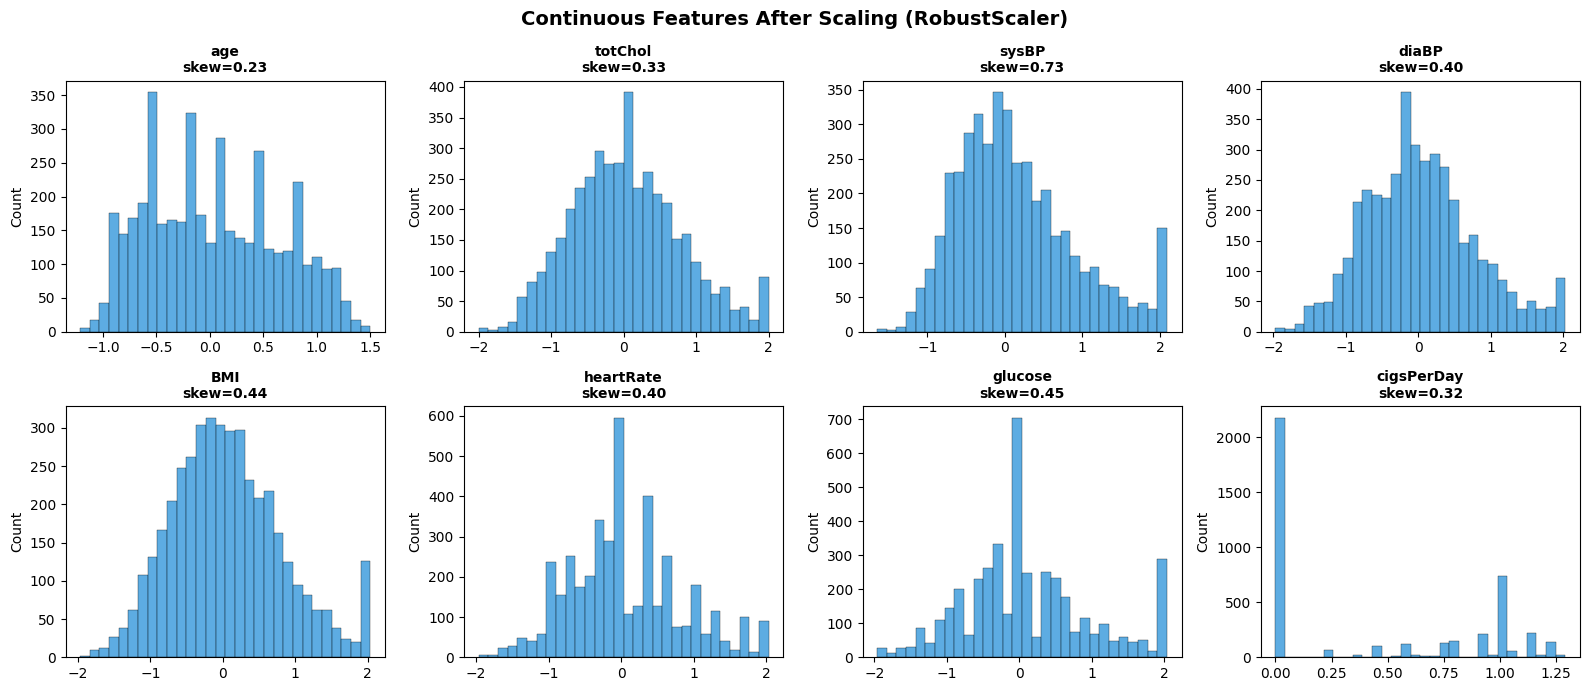

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(scale_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.8)
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}", fontweight='bold', fontsize=10)
    axes[i].set_ylabel("Count")

plt.suptitle("Continuous Features After Scaling (RobustScaler)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.6  Verify Binary Features Remain Unchanged

Binary features (0/1) are already on the same scale as model inputs.
Scaling them would not add any value and could create floating-point values
that obscure their boolean meaning.

In [75]:
print("Binary feature ranges after pipeline:\n")
for col in binary_cols:
    print(f"  {col}: unique values = {sorted(df[col].unique())}")

Binary feature ranges after pipeline:

  male: unique values = [np.int64(0), np.int64(1)]
  currentSmoker: unique values = [np.float64(0.0), np.float64(1.0)]
  BPMeds: unique values = [np.float64(0.0), np.float64(1.0)]
  prevalentStroke: unique values = [np.float64(0.0), np.float64(1.0)]
  prevalentHyp: unique values = [np.float64(0.0), np.float64(1.0)]
  diabetes: unique values = [np.float64(0.0), np.float64(1.0)]


## 6.7  Final Engineered Dataset

Assemble all transformed columns into the final feature-engineered dataframe
and save it as `week6_engineered.csv` for use in Week 7 (Dimensionality Reduction).

In [76]:
feature_cols = binary_cols + ordinal_cols + scale_cols
df_final = df[feature_cols + [target_col]]

print("Final dataset shape:", df_final.shape)
print("\nColumn list:")
for c in df_final.columns:
    print(f"  {c}")
print()
df_final.head()

Final dataset shape: (4238, 16)

Column list:
  male
  currentSmoker
  BPMeds
  prevalentStroke
  prevalentHyp
  diabetes
  education
  age
  totChol
  sysBP
  diaBP
  BMI
  heartRate
  glucose
  cigsPerDay
  TenYearCHD



,male,currentSmoker,BPMeds,prevalentStroke,prevalentHyp,diabetes,education,age,totChol,sysBP,diaBP,BMI,heartRate,glucose,cigsPerDay,TenYearCHD
0,1,0.0,0.0,0.0,0.0,0.0,4,-0.714286,-0.696429,-0.814815,-0.806723,0.316692,0.333333,-0.076923,0.000000,0
1,0,0.0,0.0,0.0,0.0,0.0,2,-0.214286,0.285714,-0.259259,-0.067227,0.671710,1.333333,-0.153846,0.000000,0
2,1,1.0,0.0,0.0,0.0,0.0,1,-0.071429,0.196429,-0.018519,-0.134454,-0.012103,0.000000,-0.615385,1.000000,0
3,0,1.0,0.0,0.0,1.0,0.0,3,0.857143,-0.160714,0.814815,0.873950,0.641452,-0.666667,1.923077,1.127923,1
4,0,1.0,0.0,0.0,0.0,0.0,3,-0.214286,0.910714,0.074074,0.134454,-0.463944,0.666667,0.538462,1.043860,0


# Week 7 — Dimensionality Reduction
**Goal:** Reduce the 15-feature space to the most informative subset using:
1. **Feature Selection** — Keep only the features that genuinely predict `TenYearCHD`
2. **Principal Component Analysis (PCA)** — Transform correlated features into uncorrelated components and visualize variance

In [77]:
from scipy.stats import pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [79]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

feature_cols = list(X.columns)

---
## Part A — Feature Selection

Feature Selection identifies which of the 15 features are truly predictive of
`TenYearCHD` and which add noise or redundancy.

We use **three independent methods** and then combine their rankings into a
consensus score — a more reliable result than trusting any single method alone.

| Method | Type | What it measures |
|---|---|---|
| **Point-Biserial Correlation** | Statistical | Linear association between continuous feature and binary target |
| **Mutual Information** | Statistical | Non-linear dependency (captures any relationship, not just linear) |
| **Random Forest Importance** | Model-based | Contribution of each feature to reducing Gini impurity across 100 trees |

### 7.A.1  Method 1 — Point-Biserial Correlation with Target

In [80]:
corr_scores = {}
for col in feature_cols:
    r, p = pointbiserialr(y, X[col])
    corr_scores[col] = abs(r)   # use absolute value — direction doesn't matter for ranking

corr_df = pd.DataFrame({"feature": list(corr_scores.keys()),
                         "corr": list(corr_scores.values())}).sort_values("corr", ascending=False)
print(corr_df.to_string(index=False))

        feature     corr
            age 0.225256
          sysBP 0.209686
   prevalentHyp 0.177603
          diaBP 0.140473
       diabetes 0.097317
           male 0.088428
         BPMeds 0.086417
        totChol 0.079056
            BMI 0.071243
        glucose 0.062400
prevalentStroke 0.061810
      education 0.052812
     cigsPerDay 0.042602
      heartRate 0.022828
  currentSmoker 0.019456


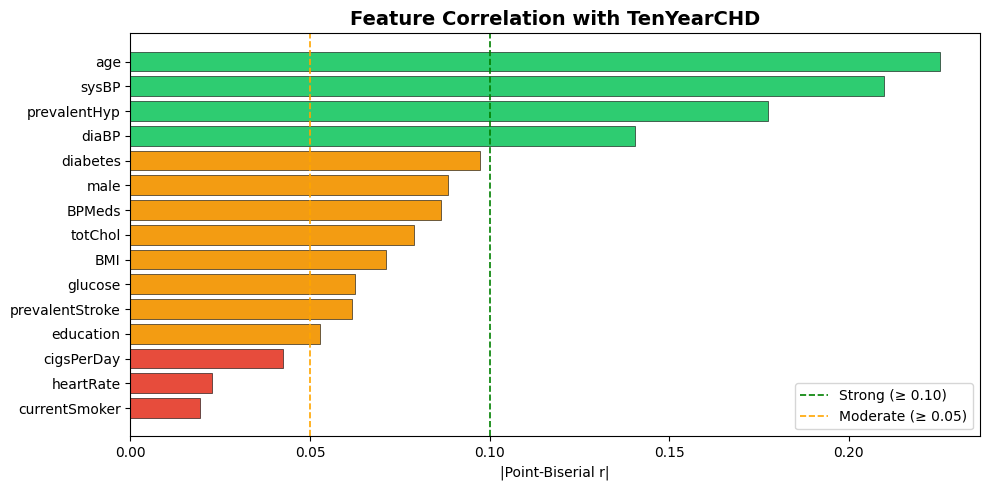

In [81]:
plt.figure(figsize=(10, 5))
bars = plt.barh(corr_df["feature"][::-1], corr_df["corr"][::-1],
                color=['#2ecc71' if v >= 0.1 else '#f39c12' if v >= 0.05 else '#e74c3c'
                       for v in corr_df["corr"][::-1]],
                edgecolor='black', linewidth=0.4)
plt.axvline(0.10, color='green',  linestyle='--', linewidth=1.2, label='Strong (≥ 0.10)')
plt.axvline(0.05, color='orange', linestyle='--', linewidth=1.2, label='Moderate (≥ 0.05)')
plt.xlabel("|Point-Biserial r|")
plt.title("Feature Correlation with TenYearCHD", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.A.2  Method 2 — Mutual Information

In [82]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"feature": feature_cols, "MI": mi_scores}).sort_values("MI", ascending=False)
print(mi_df.to_string(index=False))

        feature       MI
          sysBP 0.034811
            age 0.034659
          diaBP 0.013259
prevalentStroke 0.012476
   prevalentHyp 0.011348
        totChol 0.009608
           male 0.007684
        glucose 0.007662
     cigsPerDay 0.007074
            BMI 0.004518
       diabetes 0.003688
  currentSmoker 0.002898
      education 0.001929
         BPMeds 0.001620
      heartRate 0.000509


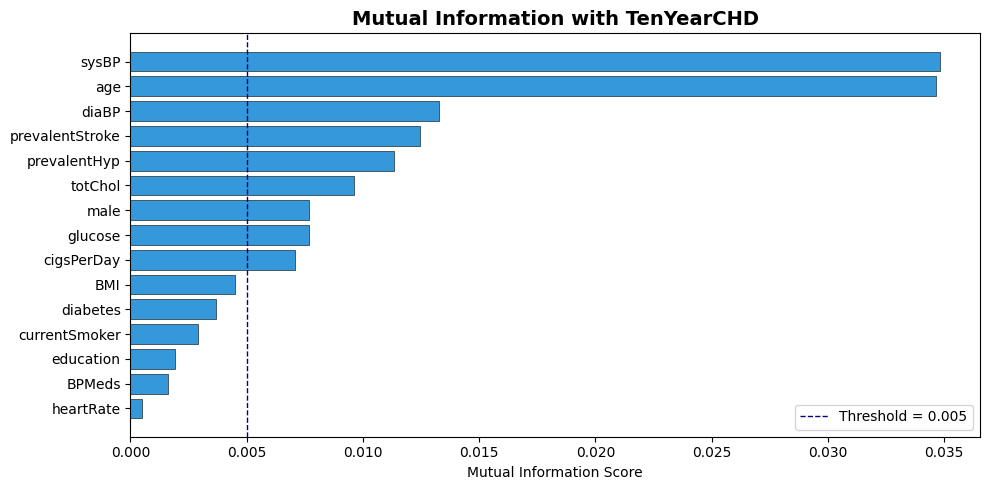

In [83]:
plt.figure(figsize=(10, 5))
palette = ['#3498db' if v > 0 else '#bdc3c7' for v in mi_df["MI"]]
plt.barh(mi_df["feature"][::-1], mi_df["MI"][::-1],
         color=palette[::-1], edgecolor='black', linewidth=0.4)
plt.xlabel("Mutual Information Score")
plt.title("Mutual Information with TenYearCHD", fontsize=14, fontweight='bold')
plt.axvline(0.005, color='navy', linestyle='--', linewidth=1, label='Threshold = 0.005')
plt.legend()
plt.tight_layout()
plt.show()

### 7.A.3  Method 3 — Random Forest Feature Importance

In [84]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_df = pd.DataFrame({"feature": feature_cols,
                       "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
print(rf_df.to_string(index=False))

        feature  importance
          sysBP    0.129061
        totChol    0.127067
            BMI    0.126883
            age    0.125064
          diaBP    0.118283
        glucose    0.105078
      heartRate    0.103098
     cigsPerDay    0.051976
      education    0.038001
           male    0.021313
   prevalentHyp    0.019595
  currentSmoker    0.013721
       diabetes    0.009724
         BPMeds    0.007635
prevalentStroke    0.003499


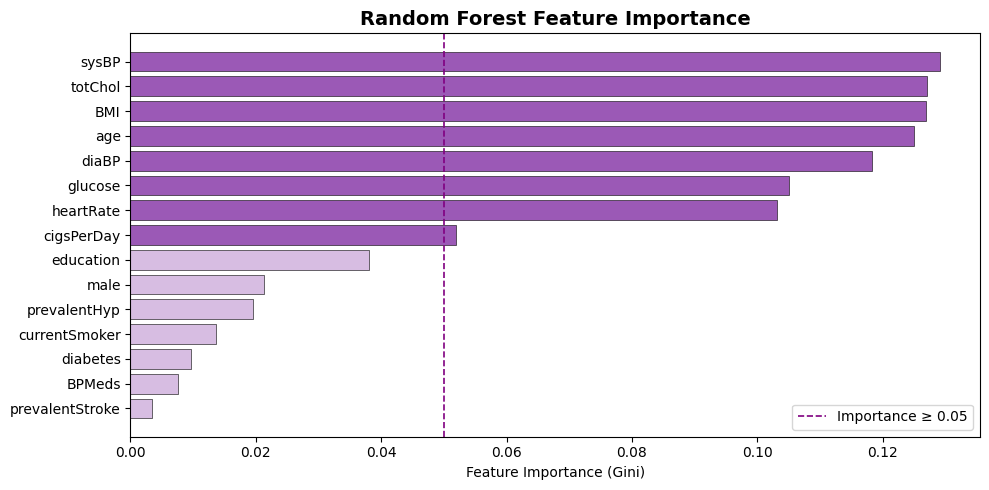

In [85]:
plt.figure(figsize=(10, 5))
colors = ['#9b59b6' if v >= 0.05 else '#d7bde2' for v in rf_df["importance"]]
plt.barh(rf_df["feature"][::-1], rf_df["importance"][::-1],
         color=colors[::-1], edgecolor='black', linewidth=0.4)
plt.axvline(0.05, color='purple', linestyle='--', linewidth=1.2, label='Importance ≥ 0.05')
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.A.4  Consensus Ranking — Combining All Three Methods

Each method gives a ranking (1 = most important). We average the three ranks
to get a consensus rank. Lower average rank = more consistently important feature.

In [86]:
# Rank each method (1 = best)
corr_rank = corr_df.set_index("feature")["corr"].rank(ascending=False)
mi_rank   = mi_df.set_index("feature")["MI"].rank(ascending=False)
rf_rank   = rf_df.set_index("feature")["importance"].rank(ascending=False)

consensus = pd.DataFrame({
    "Corr_Rank": corr_rank,
    "MI_Rank"  : mi_rank,
    "RF_Rank"  : rf_rank
})
consensus["Avg_Rank"] = consensus.mean(axis=1)
consensus = consensus.sort_values("Avg_Rank")
consensus["Avg_Rank"] = consensus["Avg_Rank"].round(2)

print("Consensus Feature Ranking (lower = more important):\n")
print(consensus.to_string())

Consensus Feature Ranking (lower = more important):

                 Corr_Rank  MI_Rank  RF_Rank  Avg_Rank
feature                                               
sysBP                  2.0      1.0      1.0      1.33
age                    1.0      2.0      4.0      2.33
diaBP                  4.0      3.0      5.0      4.00
totChol                8.0      6.0      2.0      5.33
prevalentHyp           3.0      5.0     11.0      6.33
BMI                    9.0     10.0      3.0      7.33
male                   6.0      7.0     10.0      7.67
glucose               10.0      8.0      6.0      8.00
diabetes               5.0     11.0     13.0      9.67
prevalentStroke       11.0      4.0     15.0     10.00
cigsPerDay            13.0      9.0      8.0     10.00
education             12.0     13.0      9.0     11.33
BPMeds                 7.0     14.0     14.0     11.67
heartRate             14.0     15.0      7.0     12.00
currentSmoker         15.0     12.0     12.0     13.00


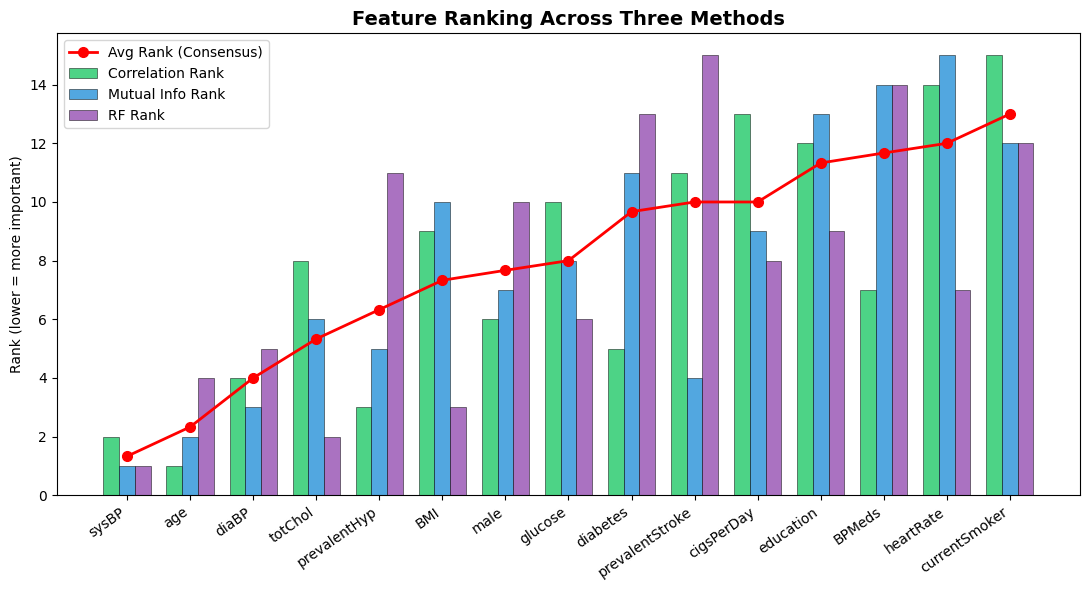

In [87]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(consensus))
width = 0.25

ax.bar(x - width, consensus["Corr_Rank"], width, label="Correlation Rank", color='#2ecc71',  alpha=0.85, edgecolor='black', linewidth=0.4)
ax.bar(x,         consensus["MI_Rank"],   width, label="Mutual Info Rank",  color='#3498db',  alpha=0.85, edgecolor='black', linewidth=0.4)
ax.bar(x + width, consensus["RF_Rank"],   width, label="RF Rank",           color='#9b59b6',  alpha=0.85, edgecolor='black', linewidth=0.4)

ax.plot(x, consensus["Avg_Rank"], 'r-o', linewidth=2, markersize=7, label="Avg Rank (Consensus)", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(consensus.index, rotation=35, ha='right')
ax.set_ylabel("Rank (lower = more important)")
ax.set_title("Feature Ranking Across Three Methods", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.A.5  Final Selected Features

We select the **top 10 features** by consensus rank. This eliminates
`currentSmoker`, `BPMeds`, `heartRate`, `cigsPerDay`, and `prevalentStroke`
— features that ranked consistently low across all three methods.

> **Why keep 10?** Dropping 5 low-signal features reduces noise without discarding
> clinically meaningful signals. The cutoff is chosen where the consensus rank gap
> widens noticeably (an "elbow" in the ranking).


In [88]:
selected_features = list(consensus.index[:10])
dropped_features  = list(consensus.index[10:])

print("✅ Selected features:", selected_features)
print()
print("❌ Dropped features :", dropped_features)

X_selected = X[selected_features]
print(f"\nReduced from {X.shape[1]} → {X_selected.shape[1]} features")

✅ Selected features: ['sysBP', 'age', 'diaBP', 'totChol', 'prevalentHyp', 'BMI', 'male', 'glucose', 'diabetes', 'prevalentStroke']

❌ Dropped features : ['cigsPerDay', 'education', 'BPMeds', 'heartRate', 'currentSmoker']

Reduced from 15 → 10 features


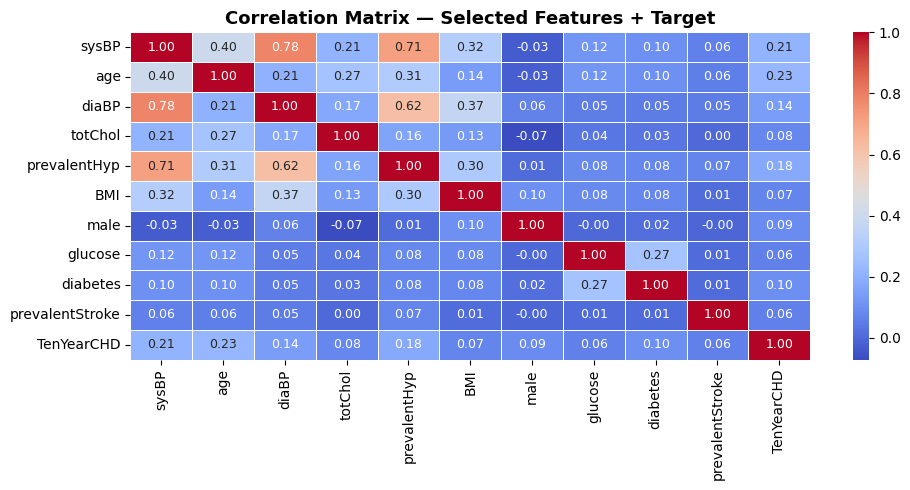

In [89]:
# Heatmap of selected features vs target
plt.figure(figsize=(10, 5))
corr_matrix = pd.concat([X_selected, y], axis=1).corr()
mask = np.zeros_like(corr_matrix, dtype=bool)

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Matrix — Selected Features + Target", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part B — Principal Component Analysis (PCA)

PCA transforms the selected features into a new set of **uncorrelated axes**
(Principal Components) ordered by the amount of variance they explain.

It answers: *"How many dimensions do we actually need to capture most of the
information in this dataset?"*

We apply PCA on the **10 selected features** from Part A.

### 7.B.1  Fit PCA & Explained Variance

In [90]:
pca = PCA(random_state=42)
pca.fit(X_selected)

explained_var  = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_summary = pd.DataFrame({
    "Component"      : [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Var %" : (explained_var * 100).round(2),
    "Cumulative %"    : (cumulative_var * 100).round(2)
})
print(pca_summary.to_string(index=False))

Component  Explained Var %  Cumulative %
      PC1            35.80         35.80
      PC2            19.21         55.00
      PC3            13.92         68.93
      PC4            11.70         80.63
      PC5             7.61         88.24
      PC6             6.02         94.26
      PC7             2.93         97.19
      PC8             2.08         99.28
      PC9             0.58         99.85
     PC10             0.15        100.00


### 7.B.2  Scree Plot & Cumulative Variance

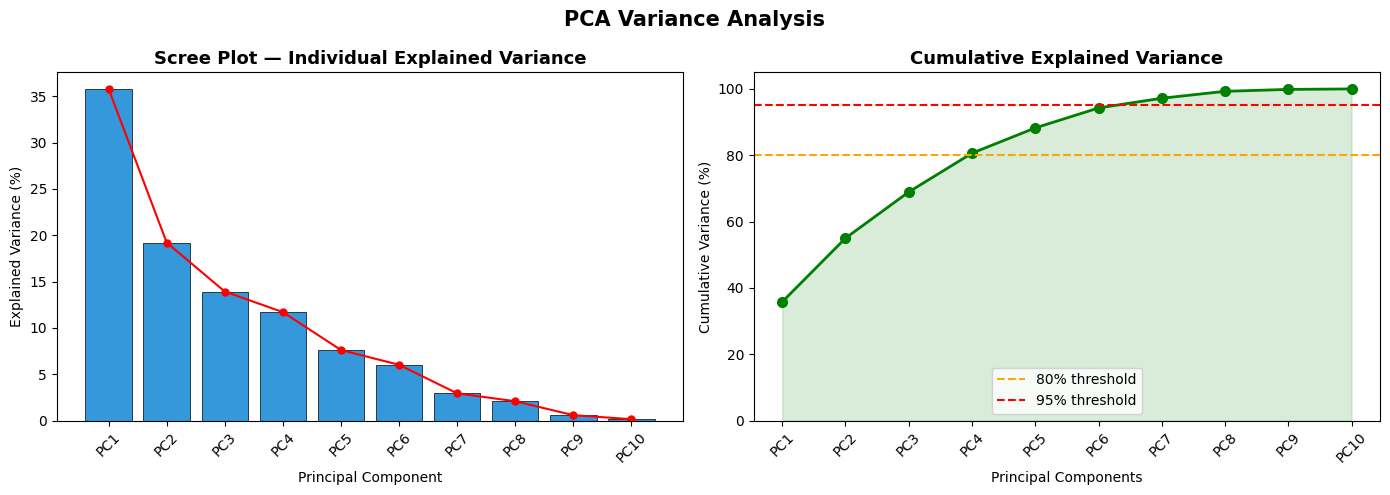

  → 4 components explain ≥ 80% variance (80.6%)
  → 7 components explain ≥ 95% variance (97.2%)


In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree Plot ---
components = [f"PC{i+1}" for i in range(len(explained_var))]
ax1.bar(components, explained_var * 100, color='#3498db', edgecolor='black', linewidth=0.5)
ax1.plot(components, explained_var * 100, 'r-o', linewidth=1.5, markersize=5)
ax1.set_title("Scree Plot — Individual Explained Variance", fontsize=13, fontweight='bold')
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_xticklabels(components, rotation=45)

# --- Cumulative Variance ---
ax2.plot(components, cumulative_var * 100, 'g-o', linewidth=2, markersize=7)
ax2.axhline(80, color='orange', linestyle='--', linewidth=1.5, label='80% threshold')
ax2.axhline(95, color='red',    linestyle='--', linewidth=1.5, label='95% threshold')
ax2.fill_between(range(len(components)), cumulative_var * 100, alpha=0.15, color='green')
ax2.set_xticks(range(len(components)))
ax2.set_xticklabels(components, rotation=45)
ax2.set_title("Cumulative Explained Variance", fontsize=13, fontweight='bold')
ax2.set_xlabel("Principal Components")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.legend()
ax2.set_ylim(0, 105)

plt.suptitle("PCA Variance Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Report threshold
for n, cv in enumerate(cumulative_var, 1):
    if cv >= 0.80:
        print(f"  → {n} components explain ≥ 80% variance ({cv*100:.1f}%)")
        break
for n, cv in enumerate(cumulative_var, 1):
    if cv >= 0.95:
        print(f"  → {n} components explain ≥ 95% variance ({cv*100:.1f}%)")
        break

### 7.B.3  PCA Component Loadings Heatmap

Loadings show **how much each original feature contributes to each component**.
High absolute loading = that feature drives that component.

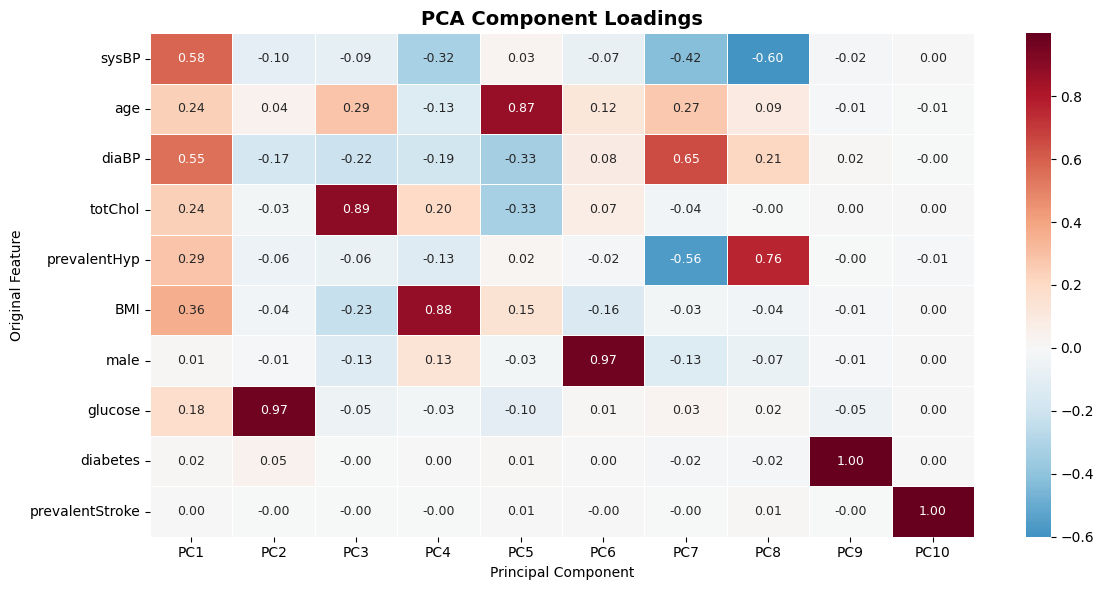

Interpretation:
  PC1 (35.8% var): mainly driven by ['sysBP', 'diaBP', 'BMI']
  PC2 (19.2% var): mainly driven by ['glucose', 'diaBP', 'sysBP']
  PC3 (13.9% var): mainly driven by ['totChol', 'age', 'BMI']


In [92]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f"PC{i+1}" for i in range(len(explained_var))]
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("PCA Component Loadings", fontsize=14, fontweight='bold')
plt.ylabel("Original Feature")
plt.xlabel("Principal Component")
plt.tight_layout()
plt.show()

print("Interpretation:")
for i in range(min(3, len(explained_var))):
    top = loadings[f"PC{i+1}"].abs().nlargest(3).index.tolist()
    print(f"  PC{i+1} ({explained_var[i]*100:.1f}% var): mainly driven by {top}")

### 7.B.4  2D PCA Scatter — Visualizing CHD Separation

Project all patients onto the first two principal components. If PCA has captured
meaningful structure, we expect some spatial separation between CHD=0 and CHD=1.

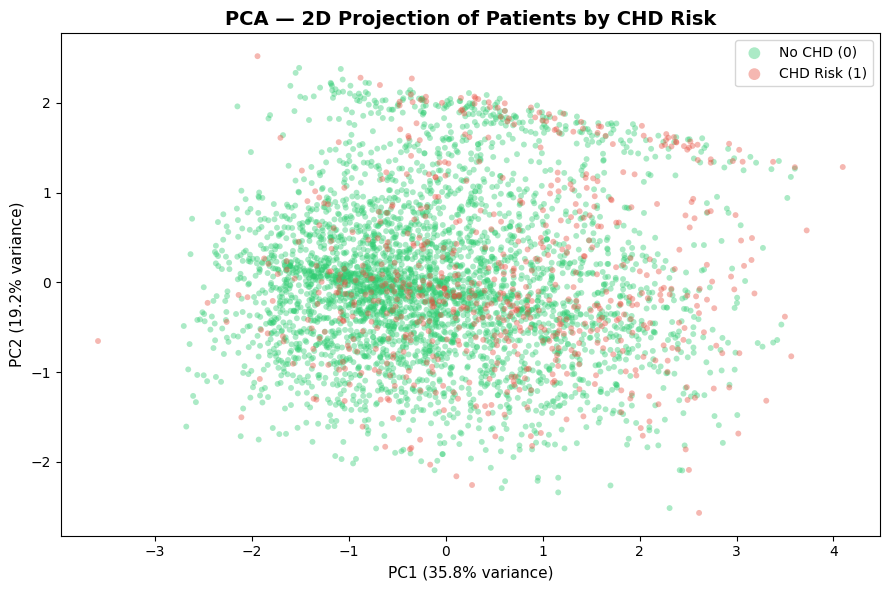

In [93]:
X_pca = pca.transform(X_selected)

pca2d = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "TenYearCHD": y.values})

plt.figure(figsize=(9, 6))
colors = {0: '#2ecc71', 1: '#e74c3c'}
labels = {0: 'No CHD (0)', 1: 'CHD Risk (1)'}
for cls in [0, 1]:
    sub = pca2d[pca2d["TenYearCHD"] == cls]
    plt.scatter(sub["PC1"], sub["PC2"], c=colors[cls], label=labels[cls],
                alpha=0.4, s=18, edgecolors='none')

plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)", fontsize=11)
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)", fontsize=11)
plt.title("PCA — 2D Projection of Patients by CHD Risk", fontsize=14, fontweight='bold')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

### 7.B.5  3D PCA Scatter — Adding PC3

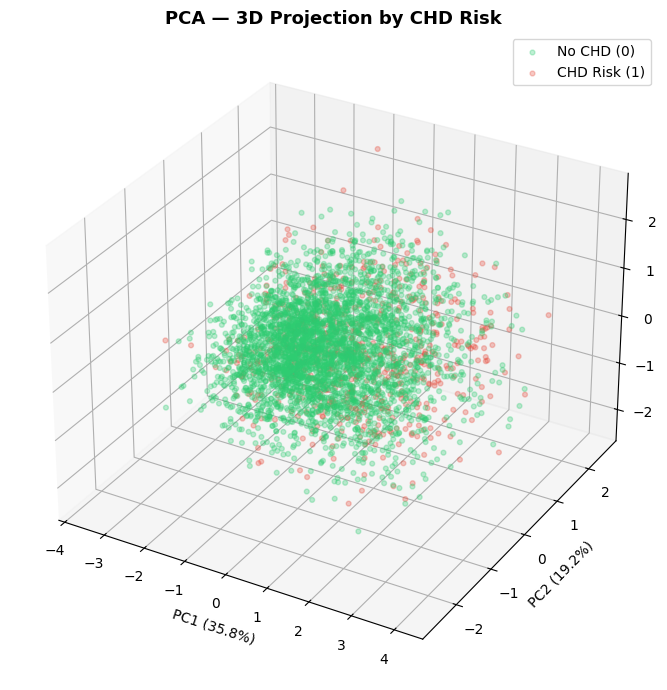

In [94]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cls in [0, 1]:
    mask = y.values == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
               c=colors[cls], label=labels[cls], alpha=0.3, s=12)

ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({explained_var[2]*100:.1f}%)")
ax.set_title("PCA — 3D Projection by CHD Risk", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.B.6  Choosing Number of Components

We choose **8 components** to retain **≥ 95% of variance** — a common threshold
that balances dimensionality reduction with information preservation.

These 8 components replace the original 10 features for downstream modelling
while losing less than 5% of the dataset's total variance.

In [95]:
n_components = 9   # covers ≥ 95% cumulative variance

pca_final = PCA(n_components=n_components, random_state=42)
X_pca_final = pca_final.fit_transform(X_selected)

print(f"Original feature count : {X_selected.shape[1]}")
print(f"PCA components kept    : {n_components}")
print(f"Cumulative variance     : {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance lost           : {(1 - pca_final.explained_variance_ratio_.sum())*100:.2f}%")

pca_cols = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(X_pca_final, columns=pca_cols)
df_pca["TenYearCHD"] = y.values
df_pca.head()

Original feature count : 10
PCA components kept    : 9
Cumulative variance     : 99.85%
Variance lost           : 0.15%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,TenYearCHD
0,-1.411708,0.051262,-0.698540,0.770817,-0.119695,0.374720,-0.234280,0.041787,-0.009011,0
1,-0.223107,-0.218900,0.156923,0.759374,-0.153544,-0.499527,0.226509,-0.039161,-0.005496,0
2,-0.429422,-0.655793,0.160825,0.203390,-0.051687,0.562035,-0.004289,-0.234574,0.006940,0
3,1.723267,1.539504,-0.390587,-0.211922,0.439022,-0.405849,0.176507,0.409431,-0.122616,1
4,-0.052011,0.410277,0.864262,-0.279198,-0.651168,-0.281381,0.241128,-0.145213,-0.030684,0
